---
title: Detecting active emotions in speech
image: ./images/ess.png
jupyter: python3
ord: 3
description: Training 5 different models to perform active emotion recognition from speech 
format:
    html:
        code-fold: true
        toc: true
        
---
      

[<img src="./images/gh.png" alt="drawing" width="100"/>](https://github.com/ViktorAnchutin/detecting_active_emotion)

In [ ]:
#| code-summary: "Init code"

!pip install transformers --quiet;
!pip install timm --quiet;

import pandas as pd
from functools import partial
from itertools import chain
import torch
from torch import nn
import gc
from data.utils import *
from transformers import Wav2Vec2Model
from experiments.models import W2V2Model, ConvNextModel
from data.dataloader import create_dataloader, MutiDataLoader
from framework.learning_rate import ExponentialLRCalculator,CosineLRCalculator
from experiments.experiment_runner import Training, TrainingConfig
from matplotlib import pyplot as plt
import torchaudio
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
w2v_features_path = 'w2v_features'

In this project I build an emotional speech detector. The goal is to train the model which can recognise active emotion in a speech segment. 

![](./images/actemo.png)

Emotions are categorised using arousal-valence model. Arousal axis mesures how active emotion is and valence measures wheather emotion is positive or negative.
I build a detector for the arousal axis, targeting the top region of the space, where emotions are the most active.
One of the applications for such a model is to apply it to detect highlights in media content from speech. 
![](./images/emotionmodel.png)

I experiment with 5 different model arhitectures. I train custom CNN-Transformer model and compare it to the pretrained models from different domains, finally I train a hybrid model combining different modalities of data.

![](./images/experiments.png)

The results are in the table below:

![](./images/results.png)

# Framework for running the experiments

The source code for the framework and experiments is published in a [Github repository](https://github.com/ViktorAnchutin/detection_active_emotion/tree/main).

For this projet I developed a custom deep learning framework to configure and run the experiments, as well as to preprocess and load the data.

Most of the models in my experiments are able to learn from mini-batches of different size. For this purpose I developed a [dataloader](https://github.com/ViktorAnchutin/detecting_active_emotion/blob/7a34326ea81658db5f823740b495b967b64aea78/data/dataloader.py#L21) which builds mini batches from the data of similar length to avoid padding overhead. 
![](./images/vb.png) 
The details of the dataloader implementation are in the blog [post](../blog/variable_length_training.ipynb).

To run the experiments I created class [Training](https://github.com/ViktorAnchutin/detection_active_emotion/blob/8eecbd2ed6c3079f40357a8290727d1ebcaf2b61/experiments/experiment_runner.py#L29) which is responsible for initializing and running the training from the provided [TrainingConfig](https://github.com/ViktorAnchutin/detection_active_emotion/blob/8eecbd2ed6c3079f40357a8290727d1ebcaf2b61/experiments/experiment_runner.py#L11).
Since some of the models are quite big I added the functionnality of mixed precision training and gradient accumulation. 

For evaluation purposes I built a [module](https://github.com/ViktorAnchutin/detection_active_emotion/blob/8eecbd2ed6c3079f40357a8290727d1ebcaf2b61/framework/metrics.py#L52) which computes such metrics as ROC-AUC, best F1 score and corresponding precision and recall. 

# Data

![](./images/mspds.png)

I am using the [MSP-Podcast](https://ecs.utdallas.edu/research/researchlabs/msp-lab/MSP-Podcast.html) dataset. It is a large naturalistic speech emotional dataset. It consists of speech segments from podcast recordings, perceptually annotated using crowdsourcing. 

I split labels into 2 categories for a binary classification task. One category contains labels corresponding to a high level of emotional activation: somewhat active, active, very active, the other contains the rest of the labels. 

![](./images/labels.png)

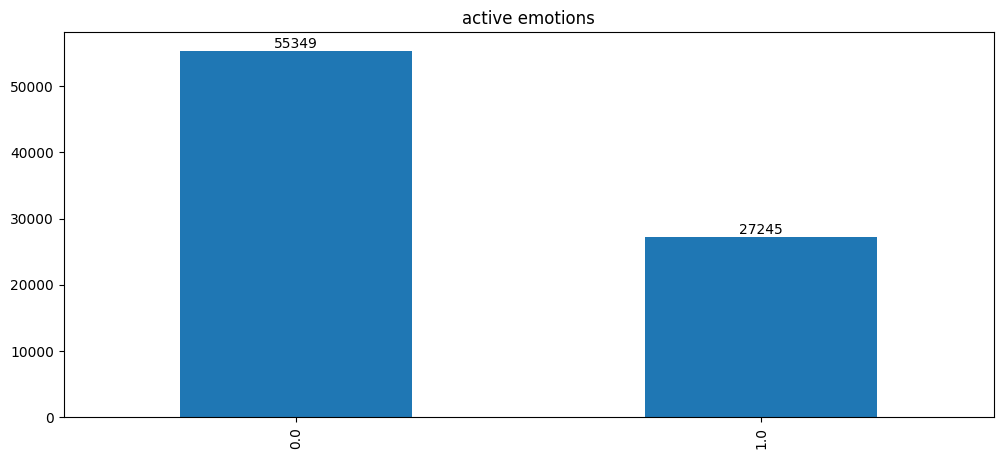

In [ ]:
data = pd.read_csv("labels_consensus.csv").set_index("FileName")
data = data[data.SpkrID != 'Unknown'] # segments without a speaker id are dropped
data['is_active'] = data.apply(lambda x: 1. if x['EmoAct'] >= 5 else 0.,axis=1)

def plot_label(data,label,ax=None,title=None):
  barc = data[label].value_counts().plot.bar(ax=ax,title=title)
  barc.bar_label(barc.containers[0], label_type='edge')

plot_label(data, 'is_active', title='active emotions');

I set a limit of 500 segments for an individual speaker in order to avoid a potential overfitting to a specific speaker.

In [ ]:
speaker_counts = data.groupby('SpkrID').apply(lambda x: pd.Series({'cnt':len(x)}))

def downsample_speaker(data,speaker,limit=500):
  sampled_ids = data[data['SpkrID'] == speaker].sample(limit).index
  todrop = data[(data['SpkrID'] == speaker)&(~data.index.isin(sampled_ids))].index
  return data.drop(todrop)

for sid in speaker_counts[speaker_counts.cnt >= 500].index:
  data = downsample_speaker(data,sid)

I perform speaker independent data split with 20% of speakers used for the test set. There's no overlap between test and test sets.

,unique speakers
custom_partition,
Test,286
Train,1146


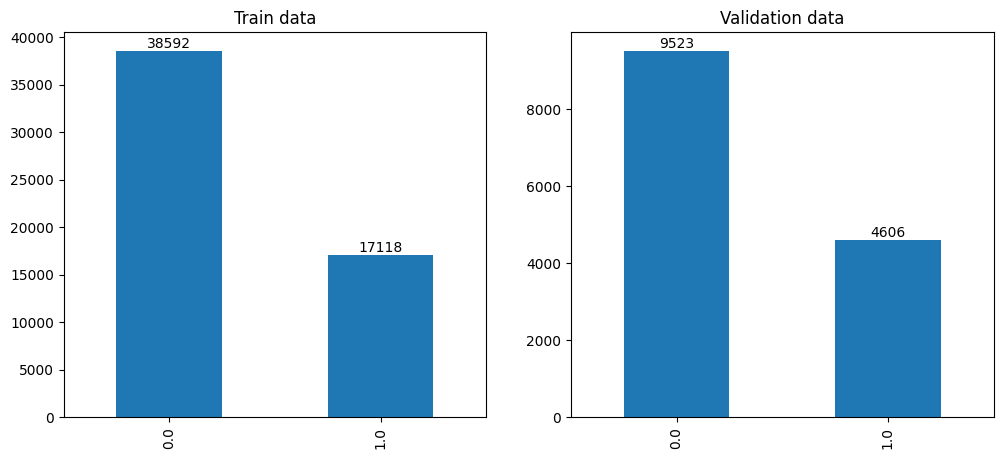

In [ ]:
speakers = data.SpkrID.value_counts()

holdout_speakers = speakers.sample(round(len(speakers)*0.2), random_state=123)
data.loc[:,'custom_partition'] = data.apply(lambda x: 'Test' if x['SpkrID'] in holdout_speakers.index else 'Train', axis=1)

train_data = data[data.custom_partition == 'Train']
valid_data = data[data.custom_partition == 'Test']

_,ax = plt.subplots(1,2,figsize=(12, 5));
plot_label(train_data, 'is_active', ax=ax[0], title='Train data');
plot_label(valid_data, 'is_active', ax=ax[1], title='Validation data');

data.groupby('custom_partition').apply(lambda x: pd.Series({'unique speakers':len(x.SpkrID.unique())}))

The infomation about the length of audio segments in seconds is collected. 

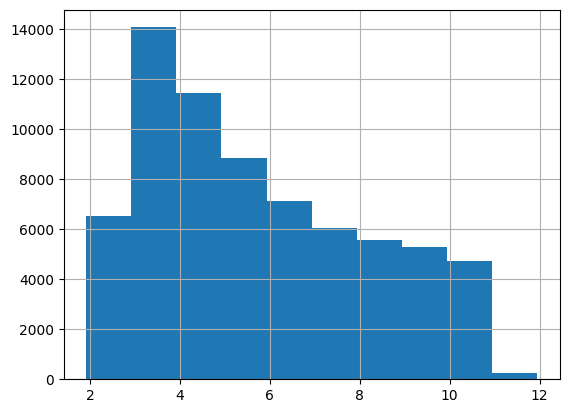

In [ ]:
files = []
durations = []
samples = []

for file_name in tqdm(data.index):
      signal, sr = torchaudio.load(f"Audios/Audio/{file_name}")
      files.append(file_name)
      durations.append(signal.shape[1]/sr)
      samples.append(signal.shape[1])

duration_df = pd.DataFrame({"file":files, "samples":samples, "dur":durations}).set_index('file')
train_data = train_data.join(duration_df)
valid_data = valid_data.join(duration_df)
duration_df.dur.hist();

Data is grouped into buckets of similar length for more efficient batching during training.  

In [ ]:
bins=20

train_data['bin'] = pd.cut(train_data.dur, bins=bins, labels=range(bins))
train_data.loc[train_data['bin']==19, 'bin'] = 18 # merge last bin due to only one record

valid_data['bin'] = pd.cut(valid_data.dur, bins=bins, labels=range(bins))

A a positive class weight is computed and it will be used in the binary cross entropy function to account for the class imbalance. 

In [ ]:
#| code-fold: false

weight = len(train_data[train_data['is_active'] == 0])/len(train_data[train_data['is_active'] == 1])

# Baseline model | CNN-Transformer

In it has been [demonstrated](https://arxiv.org/abs/2106.04803) that combining convolutions and transformers achieves state of the art results under different data sizes and computational budgets. In the ViT [paper](https://arxiv.org/abs/2010.11929) the hybrid CNN-Transformer outperformed the pure transformer model for smaller computational budgets. I use CNN-Transformer architecture for the baseline model. 

The model diagram:


<img src="./images/cnntrf.png" alt="drawing" width="400"/>

The convolutional neural network first processes F×T log mel-spectrogram and produces F' × T' × C feature map volume, where F represents the frequency dimension of a spectrogram and equals to the number of mel-filterbanks used, T - represents the time dimension and it equals to the number of time frames in a spectrogram,  (F',T') is the resolution of the produced feature map and C is the number of channels. Mean pooling is then used in the frequency dimension to produce the T'C sequence of embeddings. The obtained embeddings are then mapped to dimension D of the transformer encoder. Class token embedding is added to the beginning of the sequence. The MLP classification head is then applied to the class token after the transformer encoding stage.  

***Prepare data***

![](./images/vsd.png)

To create spectrograms I use a window size of 40ms and a hop step of 20ms with 64 mel-filterbanks. I precomputed the mean and standart deviation of the dataset, which are used for normalization. 
The model can be trained on a variable size data, so I split the data into buckets of similar length and create a dataloader for variable size data.

In [ ]:
#| code-summary: "Prepare data code"

window = 640 # 40ms
hop = 320 # 20 ms
mels=64
spctr_binned_dataset_norms = (-10.58189139511126, 14.482822057824656)

spctr_dataset_builder = partial(create_spectrogram_ds,norms=spctr_binned_dataset_norms,w=window,hop=hop,n_mels=mels)
spctr_ds_train_binned = create_binned_datasets(train_data, spctr_dataset_builder)
spctr_ds_valid_binned = create_binned_datasets(valid_data, spctr_dataset_builder)

train_dl = MutiDataLoader(spctr_ds_train_binned, partial(create_dataloader, bs=64))
valid_dl = MutiDataLoader(spctr_ds_valid_binned, partial(create_dataloader, bs=64))

Prefetch data to RAM to accelerate training:

In [ ]:
#| code-summary: "Prefetch data code"


for ds in chain(spctr_ds_train_binned,spctr_ds_valid_binned):
  ds.prefetch(1)

***Running the experiment***

Create CNN

In [ ]:
#| code-fold: false

from experiments.models import convolution_block, ResidualBlock, CustomConvTransformer

cnn = nn.Sequential(
        convolution_block(1,32),
        nn.MaxPool2d(2),
        ResidualBlock(32, 32),
        nn.MaxPool2d(2),
        ResidualBlock(32, 64),
        nn.MaxPool2d(2),
        ResidualBlock(64, 64),
        nn.MaxPool2d(2),
        ResidualBlock(64, 128),
        nn.MaxPool2d(2)
    )

Creating the [model](https://github.com/ViktorAnchutin/detection_active_emotion/blob/8eecbd2ed6c3079f40357a8290727d1ebcaf2b61/experiments/models.py#L172). Here, the CNN will produce produce a volume with 128 channels, which means the obtained embeddings will have the size of 128. I map them to 256.   

In [ ]:
#| code-fold: false

model = CustomConvTransformer(cnn,conv_emb_dim=128,target_dim=256,layers=3)

Creating the training configuration and running the experiment:

100%|██████████| 230/230 [00:07<00:00, 32.28it/s]


,train_loss,test_loss,auc,f1,recall,precision
0,0.814238,0.773414,0.793025,0.624,0.719368,0.550959


100%|██████████| 230/230 [00:07<00:00, 31.47it/s]


,train_loss,test_loss,auc,f1,recall,precision
1,0.771719,0.758556,0.801348,0.633006,0.728151,0.559851


100%|██████████| 230/230 [00:06<00:00, 36.48it/s]


,train_loss,test_loss,auc,f1,recall,precision
2,0.753767,0.758195,0.802045,0.635189,0.73408,0.559779


100%|██████████| 230/230 [00:05<00:00, 40.80it/s]


,train_loss,test_loss,auc,f1,recall,precision
3,0.734888,0.754444,0.803696,0.635551,0.741546,0.556068


100%|██████████| 230/230 [00:06<00:00, 33.63it/s]


,train_loss,test_loss,auc,f1,recall,precision
4,0.725415,0.754049,0.802665,0.635757,0.731664,0.562078


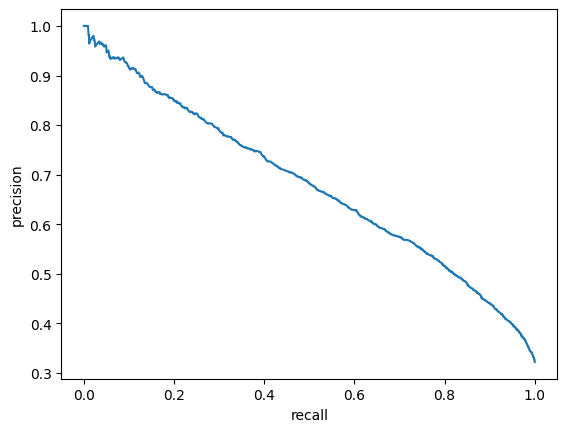

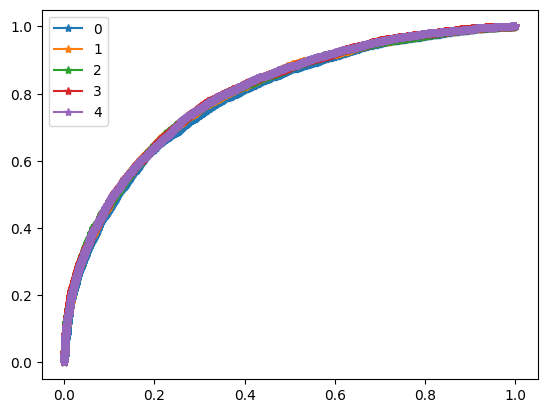

In [ ]:
#| code-fold: false

training_config = TrainingConfig(
    fine_tune = False,
    device = device,
    model = model,
    train_dl = train_dl,
    valid_dl = valid_dl,
    optimizer = torch.optim.AdamW,
    weight_decay = 3,
    positive_class_weight = weight,
    lr_calculator = ExponentialLRCalculator(factor=0.5),
    epochs = 5,
    learning_rate = 1e-4/2,
    mixed_precision = True
)

training = Training(training_config)

training.run()

# Vision transformer

Similar to [Audio Spectrogram Trasnformer](https://arxiv.org/abs/2104.01778) approach I use DeiT model. To apply vision transformer to spectrogram data several adjustments are required. 

First, spectrogram data has only 1 channel, but ViT is pretrained on images with 3 channels. It is adjusted by [summing](https://github.com/huggingface/pytorch-image-models/blob/68b2824e49c8a4442ca1c7fb29d3de8135e87c64/timm/models/_manipulate.py#L267C13-L267C63) the weights of the patch embedding layer to produce the single channel. 

Second, ViT is pretrained on images of different resolution, which means position embeddings need to be adjusted to the new size before fine-tuning. In the timm library it is [done](https://github.com/huggingface/pytorch-image-models/blob/68b2824e49c8a4442ca1c7fb29d3de8135e87c64/timm/layers/pos_embed.py#L46) using 2d interpolation. 

And finally, the both DeiT heads are replaced with new ones. The prediction is computed using late fusion as an average of the predictions from both heads.

More about applying vision models to spectrogram data in my 
<a href="../blog/Applying_vision_models_to_audio_classification.ipynb" target="_blank">blog post</a>

![](./images/adjuststeps.png)

***Prepare data***

![](./images/fld.png)

Vision transformer requires data to have fixed size due to positional embeddings. Positional embeddings have fixed size and theoretically can be interpolated during forward pass (e.g. [DINOv2](https://github.com/facebookresearch/dinov2/blob/44abdbe27c0a5d4a826eff72b7c8ab0203d02328/dinov2/models/vision_transformer.py#L200C16-L200C16)), but generally it is [not recommended](https://github.com/huggingface/pytorch-image-models/issues/908). 

All spectrograms are padded to the same length.

In [ ]:
#| code-summary: "Prepare data code"


window = 640 # 40ms
hop = 320 # 20 ms
mels=64
maxl = max(get_max_spectrogram_length(train_data,hop), get_max_spectrogram_length(valid_data,hop))
spctr_norms = (-5.612719667630828, 12.146062730351977)
spctr_dataset_train_fixed = create_spectrogram_ds(train_data, maxl=maxl,norms=spctr_norms,w=window,hop=hop,n_mels=mels)
spctr_dataset_valid_fixed = create_spectrogram_ds(valid_data, maxl = maxl,norms=spctr_norms,w=window,n_mels=mels)

Prefetch data to RAM

In [ ]:
#| code-summary: "Prefetch data code"


spctr_dataset_train_fixed.prefetch(0.5)
spctr_dataset_valid_fixed.prefetch(0.5)

***Training***

Mixed precision is used to accelerate the training.

100%|██████████| 111/111 [00:44<00:00,  2.47it/s]


,train_loss,test_loss,auc,f1,recall,precision
0,0.832366,0.810435,0.766863,0.60327,0.704875,0.527267


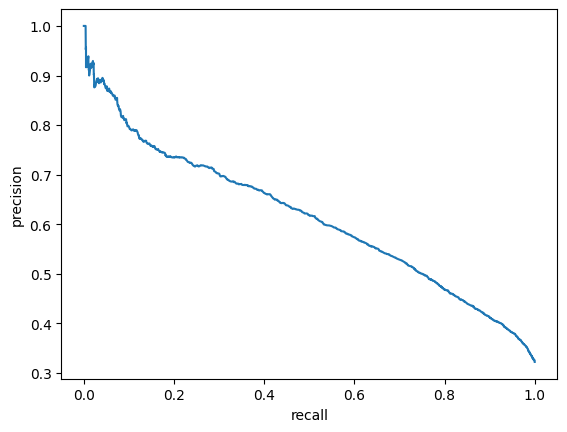

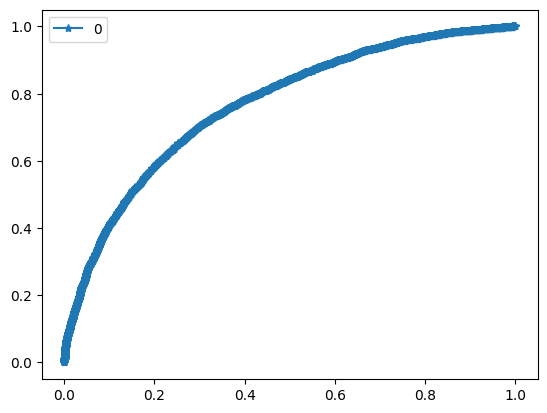

100%|██████████| 111/111 [00:44<00:00,  2.49it/s]


,train_loss,test_loss,auc,f1,recall,precision
0,0.786857,0.841773,0.797649,0.628731,0.742424,0.545235


100%|██████████| 111/111 [00:44<00:00,  2.48it/s]


,train_loss,test_loss,auc,f1,recall,precision
1,0.751145,0.801809,0.796527,0.626177,0.74484,0.540127


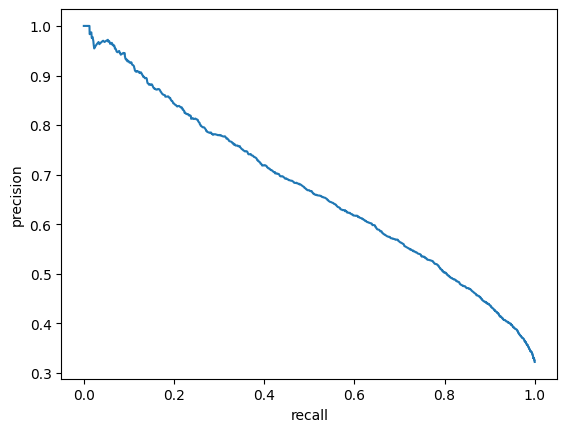

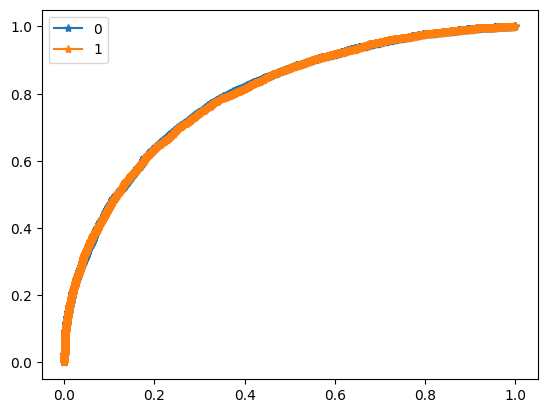

In [ ]:
#| code-fold: false


from experiments.models import ViTModel

model = ViTModel(im_size=(mels, maxl),
                 name = 'deit_tiny_distilled_patch16_224',
                 dropout=0.3)

vit_training_config = TrainingConfig(
    fine_tune = True,
    device = device,
    model = model,
    train_dl = create_dataloader(spctr_dataset_train_fixed, bs=64),
    valid_dl = create_dataloader(spctr_dataset_valid_fixed, bs=64),
    optimizer = torch.optim.AdamW,
    weight_decay = 1,
    positive_class_weight = weight,
    lr_calculator = ExponentialLRCalculator(factor=0.5),
    epochs = 2,
    head_pretrain_epochs = 1,
    learning_rate = 1e-5,
    head_pretrain_learning_rate = 1e-3,
    mixed_precision = True
)

training = Training(vit_training_config)

training.run()

# Pretrained CNN model

I'm using 'ConvNeXt' model. The first layer is adjusted to spectrogram data by [summing](https://github.com/huggingface/pytorch-image-models/blob/68b2824e49c8a4442ca1c7fb29d3de8135e87c64/timm/models/_manipulate.py#L267C13-L267C63) the weights of the input channels to produce a single channel. 
The head of the model is replaced with the fully connected layer which computes a single value for binary classification. 

***Prepare data***

![](./images/vsd.png)

CNN models can be trained on a variable size data, so similar to CNN-Transformer model I split the data into buckets of similar length and create a dataloader for variable size data.

In [ ]:
#| code-summary: "Prepare data code"


window = 640 # 40ms
hop = 320 # 20 ms
mels=64
spctr_binned_dataset_norms = (-10.58189139511126, 14.482822057824656)

spctr_dataset_builder = partial(create_spectrogram_ds,norms=spctr_binned_dataset_norms,w=window,hop=hop,n_mels=mels)
spctr_ds_train_binned = create_binned_datasets(train_data, spctr_dataset_builder)
spctr_ds_valid_binned = create_binned_datasets(valid_data, spctr_dataset_builder)

train_dl = MutiDataLoader(spctr_ds_train_binned, partial(create_dataloader, bs=64))
valid_dl = MutiDataLoader(spctr_ds_valid_binned, partial(create_dataloader, bs=64))

Prefetch data to RAM to accelerate the training

In [ ]:
#| code-summary: "Prefetch data code"


for ds in chain(spctr_ds_train_binned,spctr_ds_valid_binned):
  ds.prefetch(1)

***Training***

100%|██████████| 230/230 [00:11<00:00, 19.28it/s]


,train_loss,test_loss,auc,f1,recall,precision
0,0.878943,0.907094,0.716213,0.571478,0.726834,0.470839


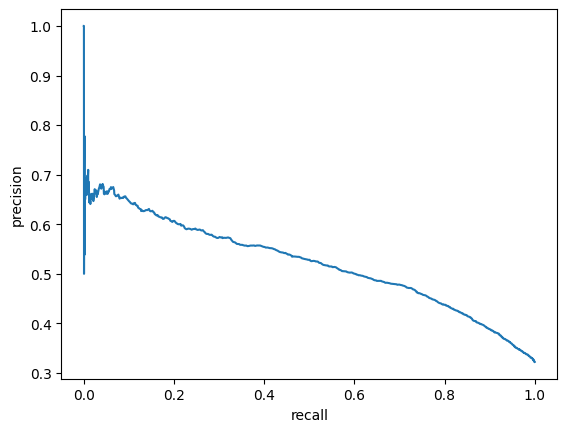

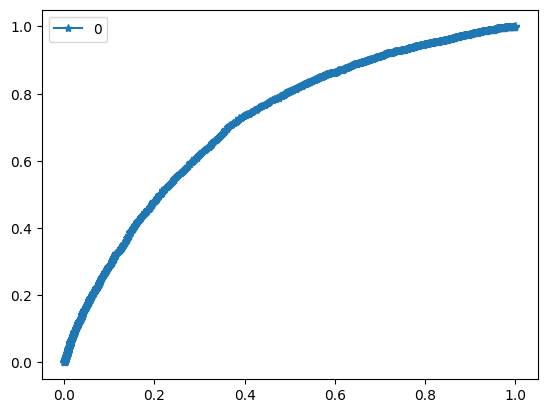

100%|██████████| 230/230 [00:12<00:00, 18.80it/s]


,train_loss,test_loss,auc,f1,recall,precision
0,0.800668,0.803675,0.804821,0.641816,0.74484,0.56383


100%|██████████| 230/230 [00:12<00:00, 19.08it/s]


,train_loss,test_loss,auc,f1,recall,precision
1,0.762559,0.750714,0.811969,0.644576,0.741107,0.570294


100%|██████████| 230/230 [00:11<00:00, 19.31it/s]


,train_loss,test_loss,auc,f1,recall,precision
2,0.740888,0.757503,0.808494,0.640108,0.726834,0.571873


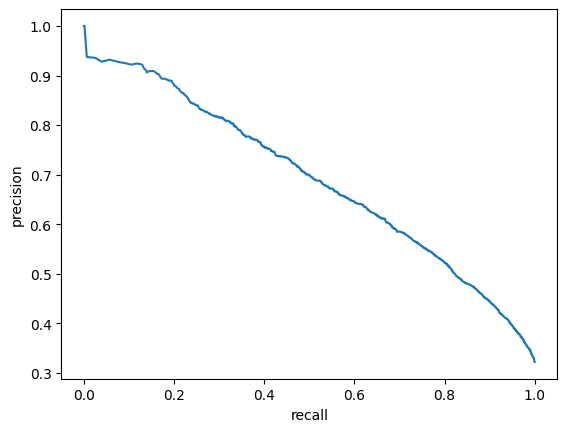

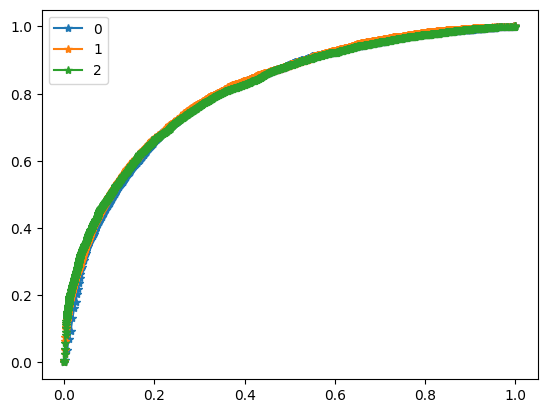

In [ ]:
#| code-fold: false


model = ConvNextModel(name = 'convnext_tiny', dropout=0.2)

training_config = TrainingConfig(
    fine_tune = True,
    device = device,
    model = model,
    train_dl = MutiDataLoader(spctr_ds_train_binned, partial(create_dataloader, bs=64)),
    valid_dl = MutiDataLoader(spctr_ds_valid_binned, partial(create_dataloader, bs=64)),
    optimizer = torch.optim.AdamW,
    weight_decay = 4,
    positive_class_weight = weight,
    lr_calculator = ExponentialLRCalculator(factor=0.5),
    epochs = 3,
    learning_rate = 1e-4/2,
    head_pretrain_learning_rate = 1e-3,
    mixed_precision = True
)

training = Training(training_config)

training.run()

# Wav2Vec 2.0

I fine tune Wav2Vec 2.0 model. The final representation vector of an audio segment is computed as an average of the sequence of vectors produced by the model.  

I add an MLP classification head on top. I keep the weights of the CNN feature encoder layer frozen, as it has been [shown](https://arxiv.org/abs/2111.02735) that it yields better results.

![](./images/wav2vec.png)

***Prepare data***

![](./images/w2vp.png)

***Precompute CNN features***

The convolutional encoder step consumes a lot of GPU. To avoid it during training, I preprocess audio segments with CNN encoder beforehand.
It is done by loading a Wav2Vec CNN feature extractor and running a forward pass on it with batches of data. The results are [saved](https://github.com/ViktorAnchutin/detection_active_emotion/blob/8eecbd2ed6c3079f40357a8290727d1ebcaf2b61/data/utils.py#L87) on disk.

In [ ]:
audios_mean,audios_sdt = (-0.00011539726044066538, 0.07812332811748154)
raw_audio_datasets_train = create_binned_datasets(train_data, partial(create_audio_ds, norms=(audios_mean,audios_sdt)))
raw_audio_datasets_valid = create_binned_datasets(valid_data, partial(create_audio_ds, norms=(audios_mean,audios_sdt)))

w2v_feature_extractor = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h").feature_extractor

!mkdir {w2v_features_path}

for ds in chain(raw_audio_datasets_train, raw_audio_datasets_valid):
  extract_w2v_features(ds, w2v_feature_extractor, w2v_features_path, bs=32, device=device)

***Create dataset and dataloader***

Wav2Vec 2.0 transformer encoder is using realtive positional embeddings which allows it to process data of variable length. The preprocessed audio files were saved on disk and here I create a dataset which groups these files by length. The corresponding dataloader is created. The batch size is only 16 as it is the maximum power of 2 size which fits into Colab's 16GB GPU memory.

In [ ]:
w2v2_datasets_train = create_binned_datasets(train_data, partial(create_file_ds, path=w2v_features_path))
w2v2_datasets_valid = create_binned_datasets(valid_data, partial(create_file_ds, path=w2v_features_path))

w2v2dl_train = MutiDataLoader(w2v2_datasets_train, partial(create_dataloader, bs=16))
w2v2dl_valid = MutiDataLoader(w2v2_datasets_valid, partial(create_dataloader, bs=16))

***Training***

I use gradient accumulation since my batch size is only 16. 
The model expects CNN encoded audio features as an input.

Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 892/892 [02:42<00:00,  5.50it/s]


,train_loss,test_loss,auc,f1,recall,precision
0,0.932333,0.92618,0.65685,0.512447,0.671278,0.414396


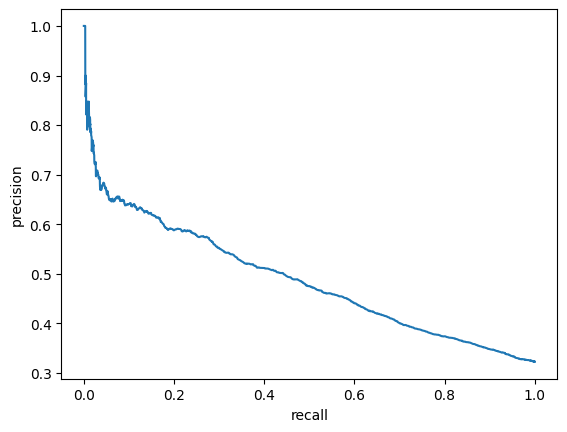

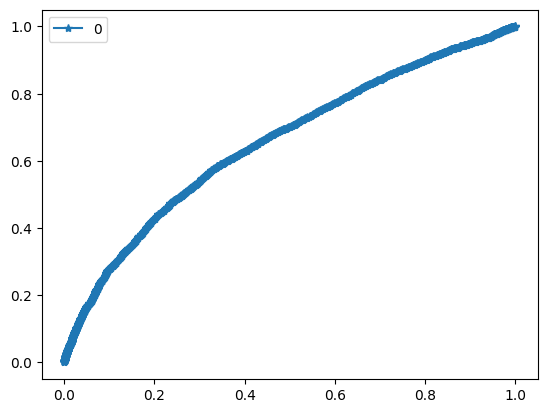

100%|██████████| 892/892 [02:42<00:00,  5.48it/s]


,train_loss,test_loss,auc,f1,recall,precision
0,0.78635,0.738586,0.817297,0.654125,0.752086,0.578743


100%|██████████| 892/892 [02:40<00:00,  5.56it/s]


,train_loss,test_loss,auc,f1,recall,precision
1,0.724516,0.74012,0.81747,0.651802,0.72859,0.589657


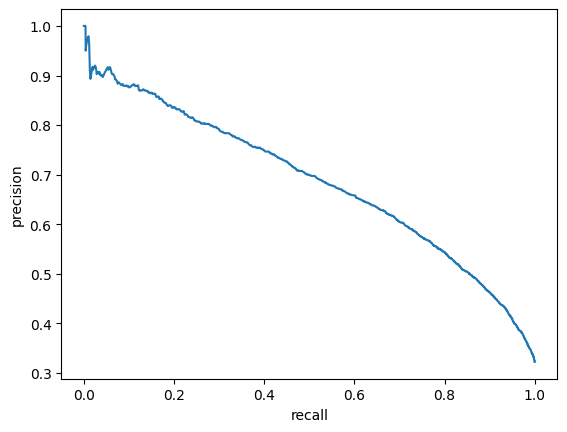

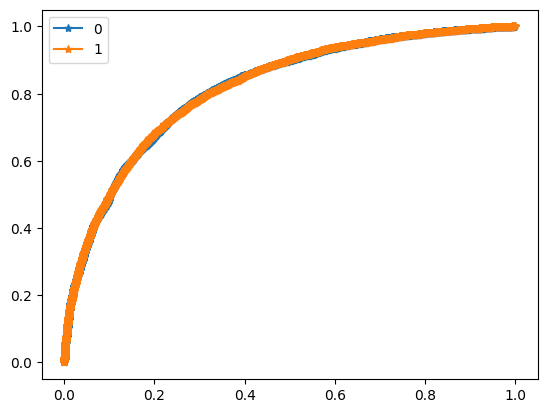

In [ ]:
#| code-fold: false


w2v_training_config = TrainingConfig(
    fine_tune = True,
    device = device,
    model = W2V2Model(),
    train_dl = w2v2dl_train,
    valid_dl = w2v2dl_valid,
    optimizer = torch.optim.AdamW,
    weight_decay = 1,
    positive_class_weight = weight,
    lr_calculator = ExponentialLRCalculator(factor=0.5),
    epochs = 2,
    head_pretrain_epochs = 1,
    learning_rate = 1e-5,
    head_pretrain_learning_rate = 1e-3,
    mixed_precision = True,
    gradient_accumulation_size = 64
)

training = Training(w2v_training_config)

training.run()

# Hybrid

The hybrid model uses both: log mel-spectrograms and raw audio data. Log mel-spectrogram modality is processed by ConvNeXt model, raw audio data is processed by the Wav2Vec 2.0 model.  

Both channels produce 1D vector representations of the input data. In the case of the ConvNeXt model I apply global average pooling for the obtained feature maps, for Wav2Vec 2.0 model I average the representation vectors it produces. The obtained 1D vectors are then projected to a lower dimension, concatenated into a single vector and sent to the classification head to produce final result. For the Wav2Vec 2.0 model I keep CNN feature encoder weights frozen. 

![](./images/hybrid.png)

***Prepare data***

I create variable length datasets for both spectrogram and wav2vec data, since both models can process variable length data.

![](./images/preprocesshybrid.png)

Create dataset for wav2vec. First create raw audio dataset, then precompute CNN encoder layer outputs. 

In [ ]:
#| code-summary: "precompute CNN features"


audios_mean,audios_sdt = (-0.00011539726044066538, 0.07812332811748154)
raw_audio_datasets_train = create_binned_datasets(train_data, partial(create_audio_ds, norms=(audios_mean,audios_sdt)))
raw_audio_datasets_valid = create_binned_datasets(valid_data, partial(create_audio_ds, norms=(audios_mean,audios_sdt)))

w2v_feature_extractor = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h").feature_extractor

!mkdir {w2v_features_path}

for ds in chain(raw_audio_datasets_train, raw_audio_datasets_valid):
  extract_w2v_features(ds, w2v_feature_extractor, w2v_features_path, bs=32, device=device)

Create a dataset from the precomputed features.

In [ ]:
#| code-summary: "Create w2v dataset"


w2v2_datasets_train = create_binned_datasets(train_data, partial(create_file_ds, path=w2v_features_path))
w2v2_datasets_valid = create_binned_datasets(valid_data, partial(create_file_ds, path=w2v_features_path))

Create a spectrogram dataset

In [ ]:
#| code-summary: "Create spectrogram dataset"


window = 640 # 40ms
hop = 320 # 20 ms
mels=64
spctr_binned_dataset_norms = (-10.58189139511126, 14.482822057824656)

spctr_dataset_builder = partial(create_spectrogram_ds,norms=spctr_binned_dataset_norms,w=window,hop=hop,n_mels=mels)
spctr_ds_train_binned = create_binned_datasets(train_data, spctr_dataset_builder)
spctr_ds_valid_binned = create_binned_datasets(valid_data, spctr_dataset_builder)

The hybrid dataset wraps spectrogram dataset and Wav2Vec dataset to produce items with 2 modalities. A variable length dataloader is created. Batch size is set to only eight items due to GPU memory limitations.

In [ ]:
#| code-summary: "Create hybrid dataset"


from data.utils import create_hybrid_datasets_binned
from data.dataloader import collate_hybrid

hybrid_datasets_train = create_hybrid_datasets_binned(w2v2_datasets_train, spctr_ds_train_binned)
hybrid_datasets_valid = create_hybrid_datasets_binned(w2v2_datasets_valid, spctr_ds_valid_binned)

hybrid_dl_train = MutiDataLoader(hybrid_datasets_train, partial(create_dataloader, collate_fn=collate_hybrid, bs=8))
hybrid_dl_valid = MutiDataLoader(hybrid_datasets_valid, partial(create_dataloader, collate_fn=collate_hybrid, bs=8))

Prefetch spectrogram part of the dataset (wav2vec features take too much memory) into RAM. 

In [ ]:
for ds in chain(hybrid_datasets_train,hybrid_datasets_valid):
  ds.prefetch(1)

***Run the training***

Gradient accumulation is enabled.

Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'wav2vec2.masked_spec_embed', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 1775/1775 [03:54<00:00,  7.57it/s]


,train_loss,test_loss,auc,f1,recall,precision
0,0.847191,0.816372,0.766683,0.607242,0.71805,0.526062


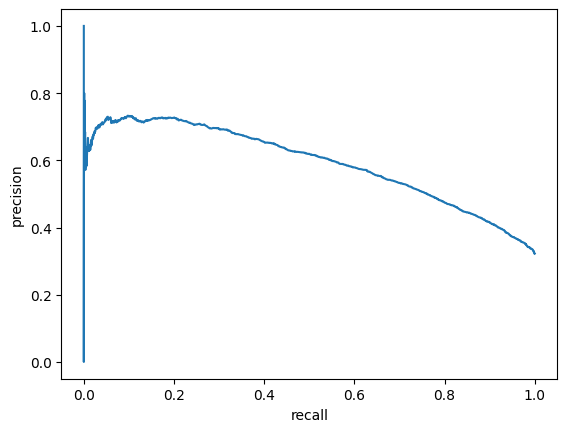

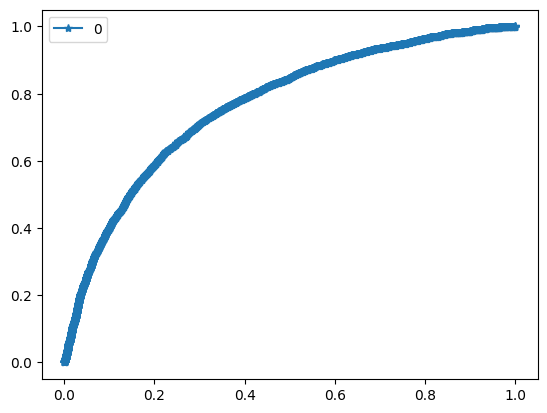

100%|██████████| 1775/1775 [04:00<00:00,  7.39it/s]


,train_loss,test_loss,auc,f1,recall,precision
0,0.769939,0.750812,0.82529,0.659073,0.71783,0.609206


100%|██████████| 1775/1775 [04:01<00:00,  7.34it/s]


,train_loss,test_loss,auc,f1,recall,precision
1,0.712602,0.732861,0.821689,0.658245,0.75516,0.583376


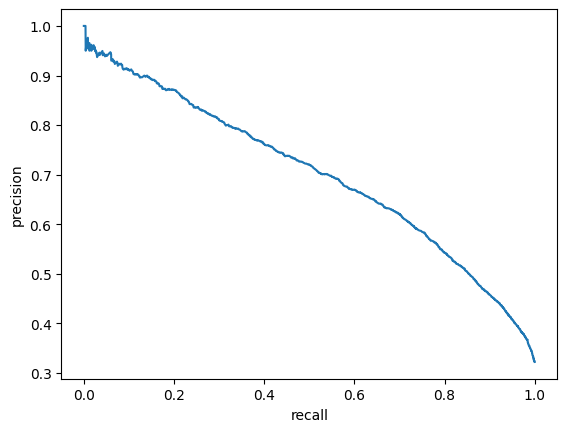

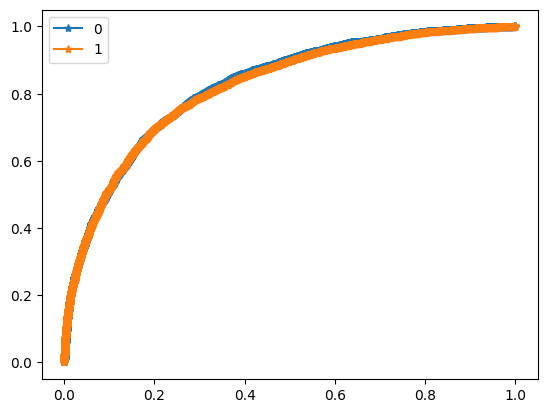

In [ ]:
#| code-fold: false


from experiments.models import HybridModel, ConvNextModel

spctr_model = ConvNextModel(name = 'convnext_tiny')
model = HybridModel(spctr_model=spctr_model)

hybrid_training_config = TrainingConfig(
    fine_tune = True,
    device = device,
    model = model,
    train_dl = hybrid_dl_train,
    valid_dl = hybrid_dl_valid,
    optimizer = torch.optim.AdamW,
    weight_decay = 1,
    positive_class_weight = weight,
    lr_calculator = ExponentialLRCalculator(factor=0.5),
    epochs = 2,
    head_pretrain_epochs = 1,
    learning_rate = 1e-5,
    head_pretrain_learning_rate = 1e-3,
    mixed_precision = True,
    gradient_accumulation_size = 64
)

training = Training(hybrid_training_config)

training.run()

Save metrics for further analysis

In [ ]:
#| code-summary: "Save metrics"


errors_report = training.trainer.cbs.callbacks[-3].get_errors_report()
errors_report.to_csv('errors_report.csv')

# Losses analysis

I analysed loss values for individual segments. Loss values are computed from the outputs of the hybrid model on the validation dataset.

In [ ]:
import numpy as np
import seaborn as sns
errors_report =  pd.read_csv('errors_report.csv', index_col=0)
errors_report['errors'] = np.where(errors_report.targ, 1-errors_report.pred, errors_report.pred)
errors_report = errors_report.set_index('id')
report = errors_report.join(valid_data)

Average loss values for different lengths of audio segments

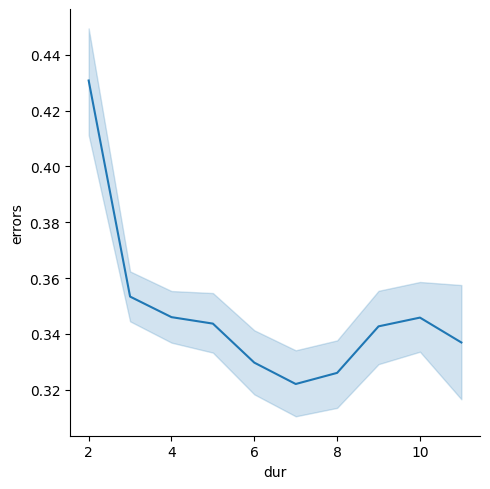

In [ ]:
sns.relplot(data=report, x=round(report.dur), y='errors', kind="line")

Average loss values for different emotional arousal levels

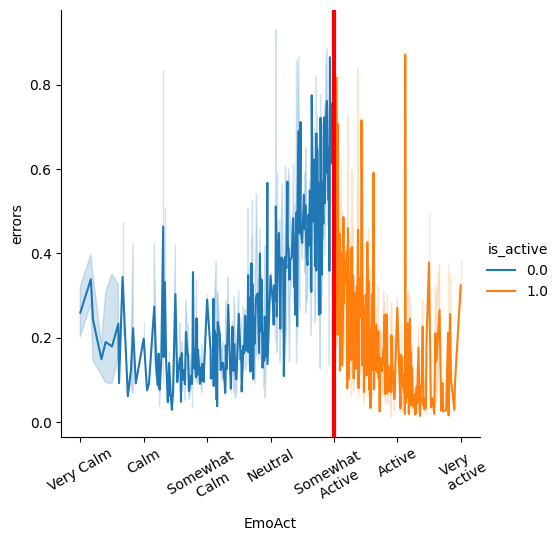

In [ ]:
sns.relplot(data=report, x="EmoAct", y="errors", kind="line", hue='is_active')
ax = plt.gca()
ax.axvline(x=5, color='r', linewidth=3)
ax.set_xticks([1,2,3,4,5,6,7])
ax.set_xticklabels(['Very Calm', 'Calm', 'Somewhat \n Calm', 'Neutral', 'Somewhat \n Active', 'Active', 'Very \n active'], rotation=30);


<Axes: xlabel='EmoAct', ylabel='errors'>

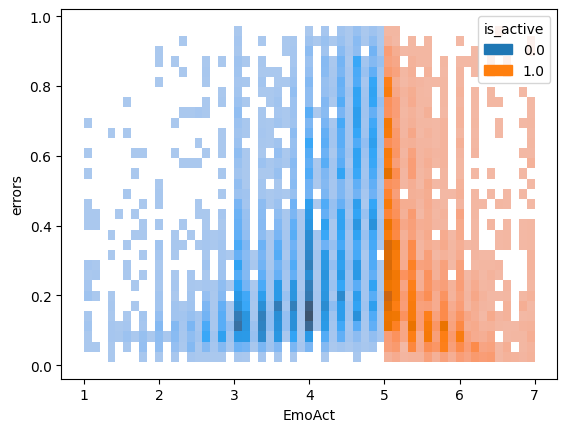

In [ ]:
sns.histplot(data=report, x="EmoAct", y="errors", hue='is_active')

# Results summary

The best results are presented in the table below

![](./images/results.png)